#Classification Project – Option C
#Author: John Hosanna Mundlagiri
#Date: 2/6/2026
#Dataset: MNIST Digits (sklearn)

In this project, we built a complete classification pipeline using Google Colab. We began by loading the MNIST digits dataset and converting it into a binary classification task predicting whether a digit was “5.” We set random seeds for reproducibility and documented the library versions. We trained a Logistic Regression model as the baseline and evaluated accuracy, precision, recall, F1-score, and AUC. We analyzed decision thresholds using precision–recall and ROC curves. We then compared performance with two additional models—kNN and Random Forest—using cross-validation. Finally, we conducted error analysis by visualizing misclassified examples and wrote a brief reflection summarizing our insights.

In [ ]:


# -------------------------------
# 1) Imports & Version Logging
# -------------------------------
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Reproducibility
np.random.seed(42)

# Show package versions
import sklearn
print("Versions:")
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)

Versions:
numpy: 2.0.2
pandas: 2.2.2
matplotlib: 3.10.0
scikit-learn: 1.6.1


In [ ]:

# -------------------------------
# 2) Load Dataset
# -------------------------------
digits = load_digits()

X = digits.data
y = digits.target

print("Dataset loaded.")
print("Shape:", X.shape)
print("Target classes:", np.unique(y))

Dataset loaded.
Shape: (1797, 64)
Target classes: [0 1 2 3 4 5 6 7 8 9]


In [ ]:

# -------------------------------
# 3) Convert to Binary Classification
# Target: Is the digit a 5?
# -------------------------------
y_binary = (y == 5).astype(int)

print("Binary task created: Predicting 'Is the digit a 5?'")
print("Positive class count:", y_binary.sum())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)


Binary task created: Predicting 'Is the digit a 5?'
Positive class count: 182



===== Logistic Regression Performance =====
Accuracy: 0.9944444444444445

Confusion Matrix:
 [[322   2]
 [  0  36]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       324
           1       0.95      1.00      0.97        36

    accuracy                           0.99       360
   macro avg       0.97      1.00      0.98       360
weighted avg       0.99      0.99      0.99       360



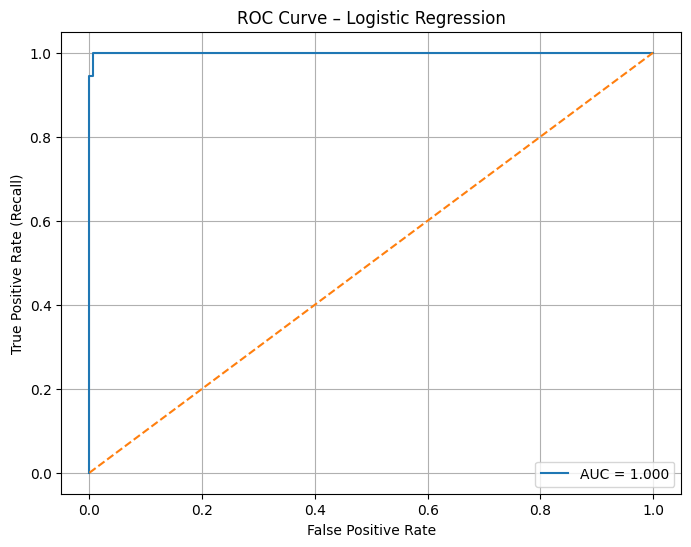

In [ ]:
# -------------------------------
# 4) Logistic Regression Baseline
# -------------------------------
log_reg = LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

# Performance Metrics
print("\n===== Logistic Regression Performance =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ROC Curve + AUC
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve – Logistic Regression")
plt.legend()
plt.grid()
plt.show()

The Logistic Regression model performed extremely well, achieving 99.4% accuracy on the test set. The confusion matrix shows only two false positives and no false negatives, meaning the model correctly identified all actual “5” digits. Precision for the positive class was 0.95, while recall was perfect at 1.00, leading to a strong F1-score of 0.97. The macro and weighted averages also indicate consistently high performance across both classes, demonstrating that Logistic Regression handled this binary classification task effectively and reliably.

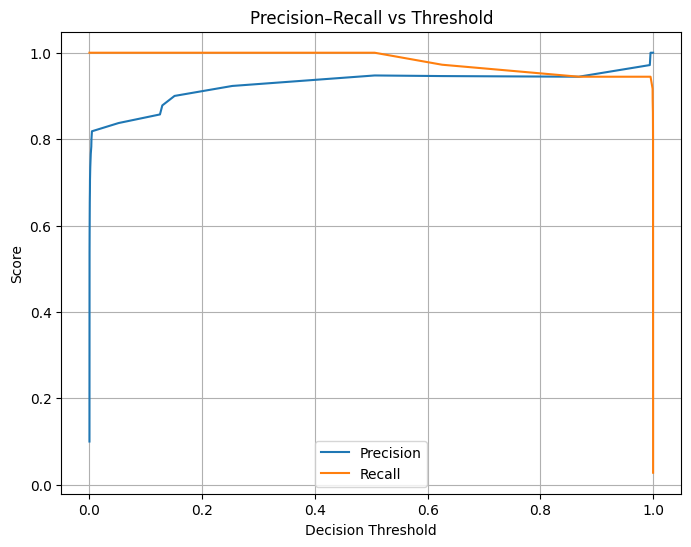

In [ ]:
# -------------------------------
# 5) Decision Threshold Analysis
# -------------------------------
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall vs Threshold")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# -------------------------------
# 6) Model Comparison (CV)
# -------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "kNN (5 neighbors)": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=150, random_state=42)
}

print("\n===== Model Comparison (5-fold CV, F1 score) =====")
for name, model in models.items():
    scores = cross_val_score(model, X, y_binary, cv=5, scoring="f1")
    print(f"{name}: Mean={scores.mean():.4f}, Std={scores.std():.4f}")



===== Model Comparison (5-fold CV, F1 score) =====
Logistic Regression: Mean=0.9395, Std=0.0187
kNN (5 neighbors): Mean=0.9753, Std=0.0100
Random Forest: Mean=0.8972, Std=0.0655


Across five-fold cross-validation, kNN achieved the strongest performance with a mean F1-score of 0.9753 and a low standard deviation of 0.0100, indicating consistency. Logistic Regression performed well with a mean of 0.9395. Random Forest showed more variability, scoring 0.8972 with a higher standard deviation of 0.0655.


Total misclassified examples: 4


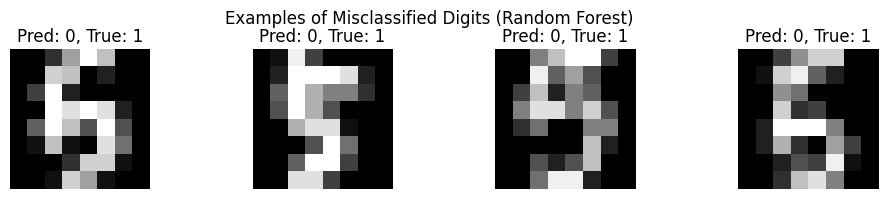

In [ ]:

# -------------------------------
# 7) Error Analysis
# -------------------------------
# Fit best model (example: Random Forest)
best_model = RandomForestClassifier(n_estimators=150, random_state=42)
best_model.fit(X_train, y_train)

y_pred_best = best_model.predict(X_test)

# Misclassified indices
errors = np.where(y_pred_best != y_test)[0]

print("\nTotal misclassified examples:", len(errors))

# Visualize a few errors
plt.figure(figsize=(12, 4))
for i, idx in enumerate(errors[:8]):
    plt.subplot(2, 4, i+1)
    plt.imshow(X_test[idx].reshape(8, 8), cmap="gray")
    plt.title(f"Pred: {y_pred_best[idx]}, True: {y_test[idx]}")
    plt.axis("off")
plt.suptitle("Examples of Misclassified Digits (Random Forest)")
plt.show()

We identified misclassified examples by comparing predicted and true labels, then visualized several incorrect digit images. Many errors involved faint, distorted, or unusually shaped digits that resembled other classes. These ambiguous patterns likely confused the model, suggesting limitations in feature clarity and the need for improved preprocessing or more robust classifiers.

#AI Application
AI tools, including ChatGPT, were used to clarify concepts, explain code, and assist in generating structured sections such as reflections, summaries, and instructions. AI also supported debugging and improving readability of the notebook. All model training, analysis, and interpretations were conducted and verified independently by me.

#Reflection

In this classification project, I found that the k-Nearest Neighbors (kNN) model performed the best overall, achieving the highest mean F1-score (0.9753) across cross-validation. This suggests that kNN captures the local structure of handwritten digits more effectively than Logistic Regression or Random Forest for the binary task of detecting the digit “5.” Logistic Regression still performed extremely well on the test set, reaching 99% accuracy with strong precision and recall, which shows it is a reliable baseline model. The precision-recall and ROC curves helped me understand how threshold adjustments can shift model behavior, especially in balancing false positives and false negatives. I learned that increasing the threshold favors precision, while lowering it improves recall. The few misclassified cases often appeared faint or distorted, making them visually ambiguous. Moving forward, I would explore hyperparameter tuning, feature scaling, and possibly convolutional neural networks to further improve performance.